# Abstract
In this development report the design process of the Hybrid Linkwitz-Riley 4 crossover Filter is described. The development was done in a docker image for integrated circuit design, which is part of an open-source kit. The subject of this development report is the design of a crossover filter, including the filter characterization and several steps of circuit design. Furthermore, the layout process is also part of this documentation. Additionally, the experiences with the open source development environment are shared as well. The filter was designed by the use of the IHP sg13g2 PDK. [GitHub Repo](https://github.com/Sriramrepaka/MCD_VS.git) 

# Introduction

Integrated circuits (ICs) have become indispensable in modern electronic systems owing to their compact form factor and reduced power consumption relative to discrete implementations, like PCBs. In this work, we present the design and implementation of a Hybrid Linkwitz-Riley 4 Crossover Filter filter using open-source tools, such as **Xschem**. The following documentation details the methodologies and development steps undertaken throughout the filter’s implementation.

This project is part of the Electronics Engineering (M. Sc.) course *“Microelectronic Circuit Design (MCD)”* at Hochschule Bremen City University of Applied Sciences (HSB).


The outcomes of this report and the development methodology used to design the filter will be made publicly available on GitHub. Everyone is welcome to use, modify, and share this work freely. This course and project would not have been possible without the excellent open-source tools created by the dedicated community of layout designers, enthusiasts, and developers. Some of the tools used include iic-osic-tools, IHP Open PDK, Docker, Xschem, ngspice, LTspice, Quarto, Python, and Git for version control.

# Filter Specifications

The filter consists of four distinct topology types, each realized using operational amplifiers (OpAmps):

* **Low-Pass (LP)**
* **High-Pass (HP)**


In this project, a fully integrated second-order Hybrid Linkwitz-Riley 4 Crossover Filter is designed, whose key specifications are given in @tbl-components :

| Parameter | Symbol | Target Value | 
|---|---|---|
| **Center Frequency**(Center frequency of the narrowband response)  | $f_0$ | 10 KHz |
| **Quality Factor**(Determines selectivity and sharpness) | $Q$ | 0.707(Butterworth Response) |
| **DC Pass-Band Gain**(Peak gain of unity at low frequencies) | $H_0$ | ~1 |

: Component selection parameters for the Linkwitz-Riley four-stage filter. {#tbl-components}

These parameters ensure a narrowband response around 10 kHz with a peak gain of unity at low frequencies and a sharp roll-off in the stop-bands.



# Behavioural Model Design

As part of the initial design process, a behavioural model of the operational amplifier was developed and simulated. This model was used to study the basic functionality of the op amp before moving toward a more detailed transistor-level implementation.

The schematic of the operational amplifier was designed using LTspice, a freely available circuit simulation tool. LTspice was used to build the behavioural representation of the op amp, verify its operation, and observe its response under different simulation conditions. This step helped in understanding the expected behaviour of the circuit and provided a useful reference for the later stages of the filter design.





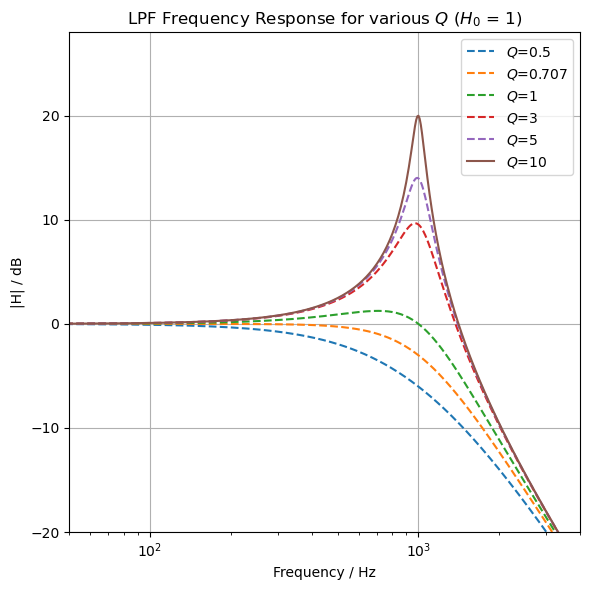

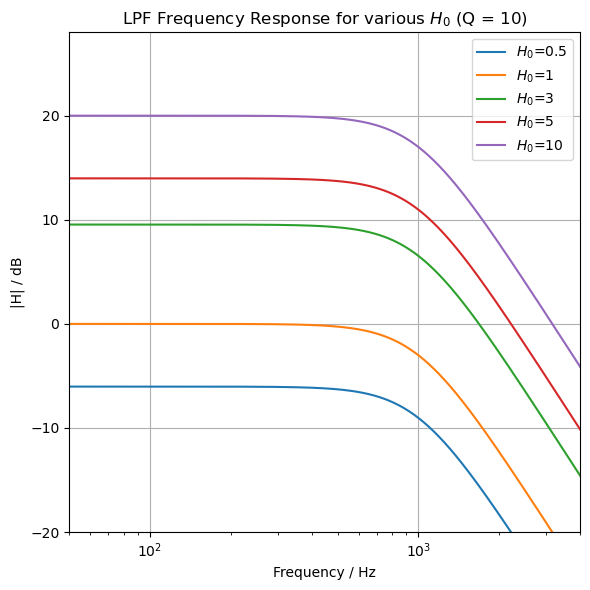

In [1]:
#| code-fold: true
#| code-summary: "Determining Suitable Quality Factor"
#| code-overflow: scroll

import numpy as np
import matplotlib.pyplot as plt

# converter
def mag2db(H):
    return 20*np.log10(np.abs(H))

# Low-Pass transfer function
def HLP(s, w0=2*np.pi*1000, Q=10, H0=1):
    return H0 / (1 + s/(w0*Q) + (s/w0)**2)

# Specs
f0    = 1000                           # Hz
w0    = 2*np.pi*f0                     # rad/s
freqs = np.linspace(1, 100*f0, 10000)  # 1 Hz to 100 kHz
s     = 1j*2*np.pi*freqs
Qs = [0.5, 0.707, 1, 3, 5, 10]
H0_vals = [0.5, 1, 3, 5, 10]


# Figure 1: LPF for different Qs (H0 = 1)

plt.figure(figsize=(6,6))
for Q in Qs:
    H = HLP(s, w0, Q, H0=1)
    style = '-' if Q==10 else '--'
    plt.semilogx(freqs, mag2db(H), style, label=f'$Q$={Q}')
plt.title('LPF Frequency Response for various $Q$ ($H_0$ = 1)')
plt.xlabel('Frequency / Hz')
plt.ylabel('|H| / dB')
plt.grid(True)
plt.xlim(50, 4000)
plt.ylim(-20, 28)
#plt.legend(loc='lower center', ncol=len(Qs), bbox_to_anchor=(0.5, -0.2))
plt.legend()
plt.tight_layout()

# Figure 2: LPF for different H_0 (Q = 0.707)

plt.figure(figsize=(6,6))
for H0 in H0_vals:
    H = HLP(s, w0, 0.707, H0)
    plt.semilogx(freqs, mag2db(H), '-', label=f'$H_0$={H0}')
plt.title('LPF Frequency Response for various $H_0$ (Q = 10)')
plt.xlabel('Frequency / Hz')
plt.ylabel('|H| / dB')
plt.grid(True)
plt.xlim(50, 4000)
plt.ylim(-20, 28)
#plt.legend(loc='lower center', ncol=len(H0_vals), bbox_to_anchor=(0.5, -0.2))
plt.legend()
plt.tight_layout()

plt.show()

## LTspice Behavioural Model Schematic

![Behavioural model schematic of the LR4 filter designed in LTspice.](images/LR4B_SCHEMATIC.png){#fig-LR4-Schematic}





The behavioural model of the four stage Linkwitz Riley filter was designed and simulated in LTspice. The schematic @fig-LR4-Schematic consists of an AC voltage source, four active filter stages, and behavioural operational amplifier models. The input signal is applied using the voltage source `V1`, which is defined with an AC magnitude of 1 V. This allows the frequency response of the circuit to be directly observed in dB during AC analysis.





### Mathematical Derivation

A standard Linkwitz-Riley 4th-order filter is constructed by cascading two identical 2nd-order Butterworth filters. The transfer function $H(s)$ for the low-pass network can be expressed mathematically as:

$$H_{LP}(s) = \frac{1}{(s^2 + \sqrt{2}s + 1)^2}$$

Where the voltage gains of both cascading stages must match perfectly to maintain the ideal crossover characteristics.

### Transfer Function and Filter Theory

The standard second-order low-pass transfer function is

$$
H(s)=\frac{\omega_0^2}{s^2+\frac{\omega_0}{Q}s+\omega_0^2}
$$

where $\omega_0$ is the natural angular frequency and $Q$ is the quality factor.

The angular frequency is related to the cutoff frequency by

$$
\omega_0 = 2\pi f_c
$$

A fourth-order Linkwitz-Riley response can be obtained by cascading two identical second-order Butterworth sections. Therefore, the LR4 transfer function is

$$
H_{LR4}(s)=H_{BW2}(s)\cdot H_{BW2}(s)
$$

This produces a fourth-order response with a steeper roll-off compared with the second-order section.

## Component Selection

The components chosen for the analog active operational amplifier implementation are summarized below.

| Component ID | Ideal Value | Chosen Value (Standard E96) | Tolerance | Function |
|--------------|-------------|----------------------------|-----------|----------|
| $R_1, R_2, R_3, R_5, R_6, R_7$   | $1.1\text{ k}\Omega$ | $1.1\text{ k}\Omega$ | $1\%$ | Filter Node Resistors |
| $R_4, R_8$   | $2.2\text{ k}\Omega$ | $2.2\text{ k}\Omega$ | $1\%$ | Filter Node Resistors |
| $C_1, C_5$   | $20\text{ nF}$         | $20\text{ nF}$         | $5\%$ | Filter Node Capacitors |
| $C_2, C_3, C_4, C_6, C_7, C_8$   | $10\text{ nF}$         | $10\text{ nF}$         | $5\%$ | Filter Node Capacitors |
| $U_1,U_2,U_3,U_4$        | OPA2134     | OPA2134                    | —         | Low-Noise Audio Op-Amp |

: Component selection parameters for the active filter stage. {#tbl-componentsxschem}

As outlined in @tbl-componentsxschem, standard resistor values are selected to match the ideal cutoff thresholds as closely as possible.

### Component Value Verification

The component values used in the behavioural model must be verified to ensure that the required crossover frequency of approximately $10\,\text{kHz}$ is obtained. The values initially presented in the component table were:

$$
R = 15.8\,\text{k}\Omega
$$

and

$$
C = 10\,\text{nF}.
$$

For a simple resistor-capacitor network, the characteristic frequency is calculated as:

$$
f_c = \frac{1}{2\pi RC}.
$$

Substituting the stated values gives:

$$
f_c =
\frac{1}
{2\pi(15.8\times10^3)(10\times10^{-9})}
\approx 1.01\,\text{kHz}.
$$

Therefore, these component values do not correspond to the specified crossover frequency of $10\,\text{kHz}$. The component table should instead contain the actual values used in the LTspice schematic.

#### Low-Pass Section

For the second-order low-pass Sallen--Key stage, the natural frequency is determined using:

$$
f_0 =
\frac{1}
{2\pi\sqrt{R_1R_2C_1C_2}}.
$$

The quality factor is calculated as:

$$
Q =
\frac{\sqrt{R_1R_2C_1C_2}}
{C_2(R_1+R_2)}.
$$

The component values (@tbl-componentsxschem) used in the low-pass section are:

| Component | Selected value |
|:--|--:|
| $R_1$ | $1.1\,\text{k}\Omega$ |
| $R_2$ | $1.1\,\text{k}\Omega$ |
| $C_1$ | $20\,\text{nF}$ |
| $C_2$ | $10\,\text{nF}$ |

Substituting these values into the frequency equation gives:

$$
f_0 =
\frac{1}
{2\pi\sqrt{
(1.1\times10^3)
(1.1\times10^3)
(20\times10^{-9})
(10\times10^{-9})
}}
$$

$$
f_0 \approx 10.23\,\text{kHz}.
$$

The corresponding quality factor is:

$$
Q \approx 0.707.
$$

This value is equal to the Butterworth quality factor:

$$
Q = \frac{1}{\sqrt{2}} \approx 0.707.
$$

#### High-Pass Section

For the second-order high-pass stage, the natural frequency is calculated using:

$$
f_0 =
\frac{1}
{2\pi\sqrt{R_3R_4C_3C_4}}.
$$

The quality factor is calculated as:

$$
Q =
\frac{\sqrt{R_3R_4C_3C_4}}
{R_3(C_3+C_4)}.
$$

The component values (@tbl-componentsxschem) used in the high-pass section are:

| Component | Selected value |
|:--|--:|
| $R_3$ | $1.1\,\text{k}\Omega$ |
| $R_4$ | $2.2\,\text{k}\Omega$ |
| $C_3$ | $10\,\text{nF}$ |
| $C_4$ | $10\,\text{nF}$ |

Substituting the selected values gives:

$$
f_0 \approx 10.23\,\text{kHz}
$$

and

$$
Q \approx 0.707.
$$

Therefore, both the low-pass and high-pass stages are designed with approximately the same natural frequency and Butterworth quality factor. Cascading two identical second-order stages in each branch produces the required fourth-order Linkwitz--Riley response.

## LTspice AC Frequency Response

![Behavioural model schematic of the LR4 filter designed in LTspice.](images/LR4B_RESULT.png){#fig-LR4-Result width=80%}


# Principle of Operation: The 5-Transistor OTA (5T-OTA)

A 5-transistor operational transconductance amplifier (5T-OTA) @fig-basic-ota is a fundamental analog building block designed to convert a differential input voltage into an output current ($G = I_{\text{out}}/V_{\text{in}}$). Unlike standard operational amplifiers that ideally feature zero output resistance, an OTA is characterized by a **high output resistance**. In practical integrated circuits, these devices are often loaded capacitively to create high-gain voltage amplifiers.

![The 5-transistor OTA [@pretl2026].](./images/fig-basic-ota-output-1.svg){#fig-basic-ota width=80%}

The internal operation of an NMOS-input 5T-OTA can be broken down into three distinct operational stages:

## NMOS Differential Pair ($M_1, M_2$)
The differential pair serves as the primary "input stage" that senses the incoming voltage signals.

**Function:** $M_1$ and $M_2$ are matched NMOS devices biased by the tail current flowing from $M_5$. When a differential input voltage is applied across their gates, it is converted into **differential drain currents** governed by the transconductance ($g_{\text{m}}$) of the transistors [@pretl2026].

**Symmetry:** In an ideal, perfectly matched scenario, if the two input voltages are identical, the tail current ($I_{\text{tail}}$) splits exactly in half ($I_{\text{tail}}/2$) down both branches.
  
## NMOS Tail Current Mirror ($M_5, M_6$)
This stage establishes the stable DC **biasing** environment required for the entire amplifier circuit.

**Function:** Transistors $M_5$ and $M_6$ form a current mirror. An external reference current ($I_{\text{bias}}$) is fed through the transistor $M_6$, which is then mirrored directly into $M_5$ [@pretl2026].

**The Tail Current:** $M_5$ operates as the **tail current source**, defining the total bias current ($I_{\text{tail}}$) that passes through the input differential pair. This tail current is a critical design parameter, as it directly sets both the transconductance ($g_{\text{m}}$) and the overall speed of the amplifier.

## PMOS Current Mirror Load ($M_3, M_4$)
This final section acts as an active load for the input pair and performs the differential-to-single-ended signal conversion.

**Function:** Transistors $M_3$ and $M_4$ form a PMOS current mirror. The diode-connected $M_3$ senses the changing current flowing through the left branch ($M_1$) and replicates it over to the right branch via $M_4$ [@pretl2026].

**Summing at the Output:** At the single-ended output node, the mirrored current from $M_4$ and the direct current from the right input branch ($M_2$) are subtracted/summed. When this net signal current is forced into the high-impedance output node, it builds up the final output voltage.

## Transistor Sizing and $g_{\text{m}}/I_{\text{D}}$ Selection Strategy

In a 5T-OTA, selecting the device sizes involves balancing fundamental trade-offs between speed, power efficiency, noise, and matching. Rather than applying a uniform $g_{\text{m}}/I_{\text{D}}$ ratio across all devices, each sub-block is targeted with a specific transconductance efficiency to maximize overall circuit performance.

---

### 1. NMOS Input Differential Pair ($M_1, M_2$)

For the input stage, a **higher $g_{\text{m}}/I_{\text{D}}$ value**—typically in the range of **10 to 12 V⁻¹**—is chosen to operate the devices in moderate inversion. 

**Gain and Power Efficiency**
: The primary goal of the input pair is to provide high transconductance ($g_{\text{m}}$) to maximize the amplifier's gain. Biasing at a high $g_{\text{m}}/I_{\text{D}}$ value achieves this required transconductance while consuming the absolute minimum current ($I_{\text{D}}$), maximizing power efficiency.

**Noise and Offset Optimization**
: Maximizing the $g_{\text{m}}/I_{\text{D}}$ ratio minimizes the overdrive voltage. This is a critical strategy for reducing the input offset voltage caused by threshold voltage mismatch between $M_1$ and $M_2$, while simultaneously minimizing the input-referred thermal noise [@nagulapalli2019low].

### 2. PMOS Load ($M_3, M_4$) and NMOS Tail ($M_5, M_6$) Current Mirrors

For the current mirror and load network, a **lower $g_{\text{m}}/I_{\text{D}}$ value**—typically in the range of **6 to 8 V⁻¹**—is chosen to operate the devices in strong inversion.

**Current Matching Accuracy**
: For current mirrors, matching accuracy takes priority over transconductance efficiency. A lower $g_{\text{m}}/I_{\text{D}}$ ratio dictates a larger overdrive voltage ($V_{\text{GS}} - V_{\text{th}}$). This larger overdrive significantly reduces current mismatch arising from local threshold voltage variations ($\Delta V_{\text{th}}$) across the mirrors.

**Output Resistance and DC Gain**
: Operating these current sources at a lower $g_{\text{m}}/I_{\text{D}}$ alongside longer channel lengths maximizes their output resistance ($r_0$). This improves both the mirroring precision and the overall DC voltage gain of the OTA [@nagulapalli2019low].

**Noise Suppression**
: To reduce the total output noise contribution of the OTA, the transconductance of the load transistors ($g_{\text{m3,4}}$) must be kept significantly lower than the transconductance of the input pair ($g_{\text{m1,2}}$). Biasing the load devices at a lower $g_{\text{m}}/I_{\text{D}}$ ensures their individual transconductance remains small, dropping their noise contribution [@nagulapalli2019low].

---

### 3. Summary Sizing Targets and Trade-offs

The table below outlines the final targeted $g_{\text{m}}/I_{\text{D}}$ configuration and the core trade-offs managing the 5T-OTA architecture, further narrowing the no of combinations. To streamline the simulation and optimization phase, the design space was restricted to tight $g_{\text{m}}/I_{\text{D}}$ windows. This dramatically reduces the number of design permutations and sweeps required during circuit characterization.

| Transistor Group | Inversion Region | Targeted $g_{\text{m}}/I_{\text{D}}$ Value | Key Design Priorities |
| :--- | :--- | :--- | :--- |
| **Input Pair ($M_1, M_2$)** | Moderate Inversion | 10 to 12 V⁻¹ | High gain, low power consumption, minimized offset. |
| **PMOS Load ($M_3, M_4$)** | Strong Inversion | 6 to 8 V⁻¹ | Low noise contribution, high output resistance, and precise current matching. |
| **NMOS Tail ($M_5, M_6$)** | Strong Inversion | 6 to 8 V⁻¹ | High output resistance for stable biasing and precise current replication. |

### Transistor Sizing and Architecture for the 5T-OTA

To determine the physical dimensions of the transistors within the 5T-OTA architecture, **$g_m/I_D$ design methodology** utilizes pre-characterized technology lookup tables

### Design Specification & Reference Parameters

The circuit dimensioning is driven by explicit performance targets, including bandwidth, capacitive loading, and transistor geometry constraints. The primary design inputs and initial assumptions are structured in @tbl-ota-specs.

| Parameter | Symbol | Initial Value / Target |
|:---|:---:|:---|
| **Load Capacitance** | $C_{\mathrm{load}}$ | $50\text{ fF}$ |
| **Target Bandwidth (-3dB Buffer)** | $f_{\mathrm{bw}}$ | $10\text{ MHz}$ |
| **Input Pair $(g_m/I_D)$** | $(g_m/I_D)_{1,2}$ | $10\text{ V}^{-1}$ |
| **Active Load $(g_m/I_D)$** | $(g_m/I_D)_{3,4}$ | $5\text{ V}^{-1}$ |
| **Tail Source current mirror $(g_m/I_D)$** | $(g_m/I_D)_{5,6}$ | $5\text{ V}^{-1}$ |
| **Assigned Channel Length (All)** | $L_{1-6}$ | $5\text{ }\mu\text{m}$ |
| **External Reference Bias Input** | $I_{\mathrm{bias,in}}$ | $20\text{ }\mu\text{A}$ |
| **Maximum Total Current Limit** | $I_{\mathrm{total,limit}}$ | $10\text{ }\mu\text{A}$ |

: Input design parameters and specifications for the 5T-OTA as per sizing document in [@pretl2026]. {#tbl-ota-specs}

---

### Sizing Derivations & Mathematical Formulations

#### Input Pair Transconductance ($g_m$) Extraction
The required transconductance for the differential input pair ($M_{1/2}$) is directly tied to the unity-gain bandwidth requirement of the system configuration. To protect against process, voltage, and temperature (PVT) variations, alongside parasitic transistor self-loading, a safety scaling factor of $3$ is introduced into the fundamental bandwidth equation:

$$g_{m1,2} = f_{\mathrm{bw}} \cdot 3 \cdot 4\pi \cdot C_{\mathrm{load}}$$

Substituting our core specifications ($10\text{ MHz}$ and $50\text{ fF}$), the script calculates the necessary small-signal capability  [@pretl2026]:

$$g_{m1,2} = 10\text{ MHz} \cdot 3 \cdot 4\pi \cdot 50\text{ fF} \approx 0.0188\text{ mS}$$

#### Bias Current Evaluation
By establishing the transconductance efficiency parameter $(g_m/I_D)_{1,2} = 10$, the single-branch bias current ($I_{D1,2}$) can be isolated:

$$I_{D1,2} = \frac{g_{m1,2}}{(g_m/I_D)_{1,2}}$$

The total tail current required from current source $M_5$ corresponds to both operational branches:

$$I_{\mathrm{total}} = 2 \cdot I_{D1,2} \approx 3.76\text{ }\mu\text{A}$$

To comply with standard layout grids and bias generation modules, this value is rounded up to a clean operational baseline of **$4.0\text{ }\mu\text{A}$** ($I_{D1,2} = 2.0\text{ }\mu\text{A}$)  [@pretl2026].

#### Gate Voltage & Physical Width Mapping
Operating at a fixed length ($L = 5\text{ }\mu\text{m}$), the calculated current and target $(g_m/I_D)$ are mapped to the semiconductor technology databases to track their native gate-to-source voltage drops ($V_{\mathrm{GS}}$):

Using the technology-specific current density value per micrometer of transistor width ($I_D/W$) provided by the lookup tables at these operating points, the physical widths ($W$) are computed via:

$$W = \frac{I_D}{(I_D/W)}$$

and rounded  [@pretl2026]

#### External Bias Current Mirroring ($M_6$)
To mirror the incoming off-chip reference current ($20\text{ }\mu\text{A}$) down to our internal tail target ($4\text{ }\mu\text{A}$), the geometry of the receiving diode-connected transistor ($M_6$) is scaled proportionally against the dimensions of $M_5$:

$$W_6 = W_{5,\mathrm{round}} \cdot \frac{I_{\mathrm{bias,in}}}{I_{\mathrm{total}}}$$

#### Open-Loop DC Gain Derivation

The open-loop DC voltage gain ($A_0$) of a single-stage 5T-OTA is defined by the transconductance of the input pair relative to the combined output conductances ($g_{\mathrm{ds}}$) of both the input transistors and the active loads. 

The total small-signal DC voltage gain is expressed using the following equation:

$$A_0 = \frac{g_{m1,2}}{g_{\mathrm{ds}1,2} + g_{\mathrm{ds}3,4}}$$

We can use the readly available sizing document to size a basic 5T-OTA, based on the input design parameters the document caculates the sizing for each transistor and other parameters like the gain, noise, power consumption and settling time. A sizing document is available at [@pretl2026]

## Transition to a Two-Stage OTA Architecture

### Why the 5T-OTA is Insufficient for Audio
While the basic 5T-OTA is simple and efficient, it is not suitable for an audio amplifier because its open-loop DC gain is only **$34.8\text{ dB}$** (around $55\text{ V/V}$). High-fidelity audio applications demand significantly more gain to minimize output distortion, and keep gain errors low. 

Because a single transistor stage cannot provide enough amplification on its own, we must transition to a **Two-Stage OTA** architecture as suggested in [@pretl2026].

### The Two-Stage Gain Equation
By cascading a second amplification stage directly after the initial differential stage, the total open-loop gain is multiplied together. The resulting total DC voltage gain is defined by the following equation:

$$A_{\mathrm{OL, total}} = A_{v1} \cdot A_{v2}$$

Where: $A_{\mathrm{OL, total}}$ is the total open-loop DC gain of the system. $A_{v1}$ is the voltage gain of the first stage (the differential input pair). $A_{v2}$ is the voltage gain of the second stage (the common-source output stage).

This structural change easily pushes the total gain into the desired range for audio quality, while the added Miller compensation network ($C_\mathrm{M}$ and $R_\mathrm{Z}$) ensures the entire circuit remains stable.

## Transistor Sizing and Architecture for the 2-Stage Miller OTA

Integral part of an Linkwitz-Riley 4 Crossover Filter is an amplifier, and a 2-stage OTA is a good option as it offers high gain and is begginer friendly design. A 2-stage OTA is essentially an 5-T OTA and a PMOS common source ampliflier cascaded with a Miller compensation capacitor $C_{\text{M}}$ and a Null resistor $R_{\text{Z}}$ as shown in @fig-2-stage-ota.

![The 2-stage OTA.](./images/fig-ota-se-twostage-output-1.svg){#fig-2-stage-ota width=80%}

There are 4 major aspects of this OTA the input differential pair, pmos current mirrors, output gain PMOS, and tail current NMOS's. The sizing of these transistors is again done using gm/Id methodology. 

### 2. Design Space Explorations: Component and Geometry Selection

To transition successfully to the two-stage architecture, two critical component adjustments were made to ensure loop stability and realistic system performance:

* **Upgrading $C_{\mathrm{load}}$ to $1\text{ pF}$ (from $50\text{ fF}$):** A $50\text{ fF}$ load only accounts for tiny, localized on-chip parasitics [@lenka2022micro]. Since this OTA is designed to drive inside an **LR4 active crossover filter** network, $1\text{ pF}$ was chosen to represent realistic load [@lenka2022micro].
* **Scaling Down $L$ to $2\text{ }\mu\text{m}$ (from $5\text{ }\mu\text{m}$):** Initial designs using $L = 5\text{ }\mu\text{m}$ suffered from severe high-frequency oscillations near the roll-off frequency. The provided technology plot reveals that an $L = 5\text{ }\mu\text{m}$ device features an extremely low transit frequency ($f_{\mathrm{T}} < 1\text{ GHz}$) as shown in the plot below. By scaling to $L = 2\text{ }\mu\text{m}$, the internal device $f_{\mathrm{T}}$ is pushed much higher (towards the $2\text{ to } 3\text{ GHz}$ range as shown in the plot below at L=1), pushing parasitic non-dominant poles safely past our operating bandwidth and eliminating the oscillations.

{{< embed /gmid/techsweep_sg13_plots_nmos.ipynb#fig-nmos-ft-vs-gmid-vs-l >}}

### Design Specification & Reference Parameters

The core target constraints, technology limits, and initial efficiency parameters are given in @tbl-2stage-specs.

| Parameter | Symbol | Initial Value / Target |
|:---|:---:|:---|
| **Load Capacitance** | $C_{\mathrm{load}}$ | $1\text{ pF}$ |
| **Target Bandwidth (-3dB Buffer)** | $f_{\mathrm{bw}}$ | $10\text{ MHz}$ |
| **Input Pair $(g_m/I_D)$** | $(g_m/I_D)_{1,2}$ | $11\text{ V}^{-1}$ |
| **Active Load $(g_m/I_D)$** | $(g_m/I_D)_{3,4}$ | $7\text{ V}^{-1}$ |
| **CS Transistor $(g_m/I_D)$** | $(g_m/I_D)_{5}$ | $10\text{ V}^{-1}$ |
| **Current Mirror $(g_m/I_D)$** | $(g_m/I_D)_{6,7,8}$ | $6\text{ V}^{-1}$ |
| **Assigned Channel Length (All)** | $L_{1-8}$ | $2\text{ }\mu\text{m}$ |
| **Target Open-Loop DC Gain** | $A_0$ | $\ge 60\text{ dB}$ |
| **Core Current Draw Budget** | $I_{\mathrm{limit}}$ | $\le 30\text{ }\mu\text{A}$ |

: Design specifications for the 2-Stage OTA. {#tbl-2stage-specs}

---

### Sizing Derivations & Mathematical Formulations

#### Compensation Allocation & First-Stage Sizing
To shield the circuit from high-frequency stability decay, a Miller capacitance ($C_\mathrm{M}$) is introduced relative to the total output load [@nagulapalli2019low]:

$$C_\mathrm{M} > 0.5 \cdot C_{\mathrm{load}} = 500\text{ fF}$$

The input pair transconductance ($g_{m1,2}$) calculation incorporates a protective $3\times$ multiplier scaling to safeguard the target bandwidth against local process tracking shifts:

$$g_{m1,2,\mathrm{ideal}} = 3 \cdot (2\pi f_{\mathrm{bw}}) \cdot C_\mathrm{M} \approx 0.09425\text{ mS}$$

Dividing by the efficiency parameter $(g_m/I_D)_{1,2} = 11$, the branch current yields a total ideal tail allocation of $I_{\mathrm{tail,ideal}} \approx 17.14\text{ }\mu\text{A}$. Quantizing this to a regular layout grid (steps of $0.5\text{ }\mu\text{A}$) locks in our tail profile:

* **Tail Current Source ($I_{\mathrm{tail}}$):** **$17.00\text{ }\mu\text{A}$**
* **True Branch Current ($I_{D1,2}$):** **$8.50\text{ }\mu\text{A}$**
* **True Manufactured Transconductance ($g_{m1,2}$):** $11 \cdot 8.5\text{ }\mu\text{A} = \mathbf{0.09350\text{ mS}}$

#### Second-Stage Stability & Resistor Calibration
To guarantee a robust design, the secondary transconductance stage ($M_5$) must easily out-pace the target operational bandwidth boundary via $(g_m/I_D)$ sizing methodology:

$$g_{m5,\mathrm{req}} = 2.2 \cdot f_{\mathrm{bw}} \cdot 2\pi \cdot C_{\mathrm{load}} \approx 0.13823\text{ mS}$$

Dividing this by its distinct parameter $(g_m/I_D)_5 = 10$ establishes the analytical current demand $I_{D5,\mathrm{req}} = 13.823\text{ }\mu\text{A}$. Mirror scaling constraints align the true current flow down to exactly **$10.00\text{ }\mu\text{A}$** based on physical layout sizes. At this grid point, the driver generates its final small-signal capability:

$$g_{m5} = (g_m/I_D)_5 \cdot I_{D5} = 10 \cdot 10\text{ }\mu\text{A} = \mathbf{0.10000\text{ mS}}$$

The zero-nulling frequency compensation resistance ($R_z$) is set to cancel the right-half-plane (RHP) zero generated across the Miller framework [@alberto2025miller]:

$$R_z = \frac{2}{g_{m5}} = \mathbf{20.00\text{ k}\Omega}$$

---

### Sizing Optimization Results

The physical layout dimensions established by mapping the grid current data back to the `pygmid` database lookup functions are structured in @tbl-2stage-results.

| Transistor Group | Geometric Layout Role | Width ($W$) | Length ($L$) |
|:---|:---|:---:|:---:|
| **$M_{1/2}$** | NMOS Input Differential Pair | $2.5\text{ }\mu\text{m}$ | $2\text{ }\mu\text{m}$ |
| **$M_{3/4}$** | PMOS Active First-Stage Load | $3.5\text{ }\mu\text{m}$ | $2\text{ }\mu\text{m}$ |
| **$M_5$** | PMOS Common-Source Output Driver | $9.5\text{ }\mu\text{m}$ | $2\text{ }\mu\text{m}$ |
| **$M_6$** | NMOS External Reference Bias Input Receiver | $2.0\text{ }\mu\text{m}$ | $2\text{ }\mu\text{m}$ |
| **$M_7$** | NMOS First-Stage Tail Current Mirror | $1.5\text{ }\mu\text{m}$ | $2\text{ }\mu\text{m}$ |
| **$M_8$** | NMOS Second-Stage Output Active Load | $1.0\text{ }\mu\text{m}$ | $2\text{ }\mu\text{m}$ |

: Final optimized structural dimensions for the 2-Stage Miller OTA. {#tbl-2stage-results}

The sizing procedure and its calculation are best performed in a Jupyter notebook, as we can easily look up the exact data from the pre-computed lookup tables:

::: {.callout-tip title="Notebook 2-Stage-OTA Sizing" collapse="true"}
{{< embed /gmid/sizing_2_stage_ota.ipynb echo=true >}}
:::

---

### Open-Loop DC Gain & Performance Evaluation

By splitting the design across cascaded active blocks, the total system gain successfully clears the targets required. The cumulative performance metrics are detailed in @tbl-2stage-perf.

| Performance Metric | Design Value | Status / Constraint |
|:---|:---:|:---|
| **Stage 1 Gain ($A_1$)** | **$31.6\text{ dB}$** | Primary Voltage Boost |
| **Stage 2 Gain ($A_2$)** | **$34.3\text{ dB}$** | Secondary Common-Source Boost |
| **Total Open-Loop Gain ($A_0$)** | **$65.9\text{ dB}$** | **Passed** ($\ge 60\text{ dB}$ Target) |
| **Voltage Gain Error | **$-0.1\%$** | Passes a target of $<0.3%$ |
| **Core Branch Current Draw** | **$27.00\text{ }\mu\text{A}$** | **Passed** ($\le 30.00\text{ }\mu\text{A}$ Budget) |
| **Peak Power Dissipation** | **$72.85\text{ }\mu\text{W}$** | Simulated at $V_{\mathrm{DD,max}} = 1.55\text{ V}$ |
| **Predicted Layout UGBW** | **$24.82\text{ MHz}$** | Exceeds $10\text{ MHz}$ baseline specification |

: Performance summary of the 2-Stage Miller OTA configuration. {#tbl-2stage-perf}

## 2-Stage OTA Simulation Framework and Results

To validate the analytical sizing derivations and empirical stability optimizations, the design was constructed and verified inside the **Xschem** schematic capture environment utilizing the **IHP SG13G2** open-source PDK. 

### Simulation Environment Setup
The core amplifier design and its folders :

* **`ota-2stage.sch` & `ota-2stage.sym`:** The fundamental schematic and corresponding symbol containing the optimized geometric sizing (e.g., $L = 2\text{ }\mu\text{m}$, $C_{\mathrm{M}} = 0.9\text{ pF}$, and $R_{\mathrm{z}} = 24\text{ k}\Omega$).

To evaluate the design against all primary performance metrics, three separate testbenches were built in the same workspace folder:

1. **`ota-2stage_tb-ac.sch`:** Small-signal AC analysis to characterize closed-loop DC gain ($A_0$), and Unity-Gain Bandwidth ($f_(bw)$) as shown in @fig-2-stage-ac-response.
2. **`ota-2stage_tb-trans.sch`:** Transient analysis to verify step-response behavior and settling time.
3. **`ota-2stage_tb-noise.sch`:** Noise spectrum evaluation.

![2-Stage OTA AC response testbench.](./xschem/ota-2stage_tb-ac.svg){#fig-2-stage-ac-response}

---

### Key Simulation Performance Results

The simulation runs verified that the optimized pole-splitting configuration successfully resolves the high-frequency stability challenges encountered in early design cycles. 

#### 1. Small-Signal AC Response
The AC characterization plots confirm an exceptionally clean frequency roll-off profile:

* **Unity-Gain Bandwidth ($\text{UGBW}$):** The simulated crossover frequency measures safely **above the $10\text{ MHz}$ minimum requirement**.
* **Loop Stability:** Thanks to the Left-Half Plane (LHP) zero tracking added by the $24\text{ k}\Omega$ nulling resistor ensuring no risk of ringing or oscillation.

![2-Stage OTA AC response.](./xschem/simulations/ota-2stage_tb-ac-result.svg){#fig-2-stage-ac-response-result width=80%}

#### 2. Transient and Noise Fidelity
* The transient step response simulation (`ota-2stage_tb-trans.sch`) shows a well-behaved, symmetric settling behavior with minimal overshoot.
* The noise simulation (`ota-2stage_tb-noise.sch`) verifies that the input-referred noise voltage is kept low.

## Sallen-Key Low-Pass Filter Integration

To evaluate the 2-stage Miller OTA within its intended system environment, it was integrated into a 2nd-order Sallen-Key Active Low-Pass Filter (LPF). The target design metric requires a strict **$-6\text{ dB}$ i.e $Q$ = 0.5 cutoff frequency ($f_{\mathrm{c}}$) at exactly $10\text{ kHz}$**.

### Passive Network Synthesis & Load Matching
Initial design attempts using standard textbook equal-component formulas yielded impractical results. To synthesize realistic on-chip values, the **Okawa-Denshi Active Filter Design Tool** [@okawa_sallen_key] was utilized to compute a the requires R and C values. 

By setting the targeted performance constraints ($f_{\mathrm{c}} = 10\text{ kHz}$) and intentionally mapping the capacitor values to align with the OTA's engineered load limit ($C_{\mathrm{load}} = 1\text{ pF}$), the network parameters were locked in:

* **Input-Assigned Capacitors:** $C_1 = 0.9\text{ pF}$, $C_2 = 0.4\text{ pF}$
* **Synthesized Tool Resistors:** $R_1 = 68\text{ M}\Omega$, $R_2 = 10\text{ M}\Omega$

### Filter Characterization Results
With the synthesized asymmetric resistor network implemented in the Xschem testbench , the active filter architecture functions exactly as intended:

* **Frequency Tuning:** The ac responce successfully achieves a stable attenuation slope with the desired $-6\text{ dB}$ cross-over breakpoint localized around **$10\text{ kHz}$**.

::: {.callout-note title="Verification Testbench Workspace"}
All verification testbenches are present in the `./xschem` workspace directory. Each setup used the exact same core `ota-2stage.sym` symbol, relying on the asymmetric impedance matching profiles calculated from the Okawa-Denshi design tool [@okawa_sallen_key]:

`ota-2stage_tb-sk-lpf.sch`, `ota-2stage_tb-sk-hpf.sch`, `ota-2stage_tb-lr2.sch` and `ota-2stage_tb-biquad.sch`
:::

# Linkwitz–Riley Fourth-Order (LR4) Crossover Filter

In addition to the two-stage OTA design, a fourth-order Linkwitz–Riley (LR4) crossover filter was implemented to investigate higher-order active filter design. The Linkwitz–Riley crossover is widely used in audio applications because it provides a flat summed frequency response when the low-pass and high-pass outputs are combined.

An LR4 crossover is obtained by cascading two identical second-order Butterworth filter sections. Since a second-order Butterworth filter has a quality factor

$$Q = \frac{1}{\sqrt{2}}\approx0.707$$

each stage was implemented using a Sallen–Key topology with a cutoff frequency of 10 kHz. The output of the first stage was connected directly to the input of the second stage, resulting in a fourth-order response.

The same design procedure was followed for both the low-pass and high-pass branches. A common input signal was applied to both branches, and the individual frequency responses were simulated.

The resulting LR4 crossover exhibits the following characteristics:

- Fourth-order response (80 dB/decade roll-off)
- Cutoff frequency of 10 kHz
- −6 dB gain at the crossover frequency
- Flat summed response when the low-pass and high-pass outputs are combined

The component values are again derived from [@okawa_sallen_key] tool and the values used are shown in the table below.

## Component values for the Linkwitz–Riley crossover

| Component | Stage 1 LPF | Stage 2 LPF | Stage 1 HPF | Stage 2 HPF |
|-----------|------------:|------------:|------------:|------------:|
| R1 | 37.5 M$\Omega$ | 37.5 M$\Omega$ | 18.7 M$\Omega$ | 18.7 M$\Omega$ |
| R2 | 37.5 M$\Omega$ | 37.5 M$\Omega$ | 37.4 M$\Omega$ | 37.4 M$\Omega$ |
| C1 | 0.6 pF | 0.6 pF | 0.6 pF | 0.6 pF |
| C2 | 0.3 pF | 0.3 pF | 0.6 pF | 0.6 pF |
| Cutoff Frequency | 10 kHz | 10 kHz | 10 kHz | 10 kHz |
| Quality Factor (Q) | 0.707 | 0.707 | 0.707 | 0.707 |

## Simulation Environment Setup
The core filter design testbench schematic using the same `ota-2stage.sym` is present in `ota-2stage_tb-sk-LR4.sch` which is shown below in figure [@fig-2-stage-LR4-tb]

![4th-order Linkwitz–Riley crossover filter testbench](./xschem/ota-2stage_tb-sk-LR4.svg){#fig-2-stage-LR4-tb}

The following are the frequency and phase response of the simulated hybrid LR4 testbench. 

![4th-order Linkwitz–Riley crossover filter frequency response](./xschem/simulations/lr4_frequency_response.svg){#fig-2-stage-LR4-freq-res width=70%}

![4th-order Linkwitz–Riley crossover filter Phase response](./xschem/simulations/lr4_phase_response.svg){#fig-2-stage-LR4-tb-ph-res width=70%}

# Process, Voltage, Temperature (PVT) and Monte Carlo (MC) Verification

## Methodology and Objectives (Why it is Required)
A nominal circuit simulation operating solely at typical-typical (TT) manufacturing process parameters, fixed nominal supply voltages, and a constant room temperature ($27^\circ\text{C}$) provides an incomplete representation of real-world silicon performance. To guarantee high-yield manufacturability and operational robustness, the design must be validated against random environmental fluctuations and process parameters:

1. **Environmental and Operational Variations (Voltage and Temperature):** Power supply networks experience dynamic regulation tolerances, and environmental operating temperatures shift based on load and ambient conditions. The circuit must preserve properties across these extreme shifts  [@pretl2026].
2. **Systemic Manufacturing Excursions (Process Corners):** Standard wafer fabrication introduces predictable deviations in threshold voltages ($V_{\text{th}}$), oxide thicknesses ($t_{\text{ox}}$), and carrier mobilities ($\mu$). Foundries quantify these boundaries through five discrete device corners: **TT** (Typical-Typical), **SS** (Slow-Slow), **SF** (Slow-Fast), **FS** (Fast-Slow), and **FF** (Fast-Fast) [@pretl2026]. 
3. **Random Local Mismatch (Monte Carlo):** Distinct from macroscopic wafer-to-wafer process variations, adjacent transistors on the same die experience microscopic, localized geometric differences (such as edge roughness or local dopant fluctuations). This mismatch induces random offsets, altering matching-critical parameters like input-pair symmetry, open-loop gain uniformity, and filter pole stability [@pretl2026].

Evaluating every combination of these variables creates a vast, multi-dimensional simulation space that must be systematically evaluated against pass/fail design metrics.

## Implementation Framework (How it is Executed)

To efficiently execute this extensive matrix without relying on manual, error-prone testbench modifications, the verification architecture utilizes **CACE (Circuit Automatic Characterization Engine)**. 

CACE acts as an automated simulation runner that structures, parallelizes, and sweeps the design space via a unified, programmatically driven pipeline:

::: {.callout-warning title="Running CACE Simulation"}

The CACE simulation run can be started with

```bash
cace cace/lpf-ota-2stage.yaml
```

The simulation results are then placed into the `cace/_docs` folder. If in addition to the default Markdown report an HTML output is needed for easier review then using Pandoc it can be easily converted and viewed with with 

```bash
cace/cace_view.sh cace/_docs/ota-2stage_schematic.md
```

:::

After a successful run, a documentation is automatically generated. The result of a full run of this 2 stage ota is presented here:

::: {#nte-2-stage-ota-cace-result .callout-note title="CACE Summary for 2-Stage-OTA and LR4 filter" collapse="true"}

<div class="top-scrollbar-wrapper" style="overflow-x: auto; overflow-y: hidden; width: 100%;" onscroll="document.getElementById('cace-content-wrapper').scrollLeft = this.scrollLeft;">
  <!-- This empty div matches the wide content size to force the scrollbar to appear -->
  <div style="width: 250%; height: 1px;"></div>
</div>

<!-- 2. The Main Content Container (Bottom Scrollbar) -->
<div id="cace-content-wrapper" style="overflow-x: auto; max-width: 100%;" onscroll="document.getElementsByClassName('top-scrollbar-wrapper')[0].scrollLeft = this.scrollLeft;">

{{< include /cace/_docs/ota-2stage_schematic.md >}}

</div>

:::

# PVT Simulation Analysis

Looking at the CACE report in @nte-2-stage-ota-cace-result, we see that (luckily) the specification is met for all parameters. This is great news! We now have a design that we carefully simulated across PVT and other corners and that is ready for layout. 

## Monte Carlo Simulation Analysis

Looking at the CACE report in @nte-2-stage-ota-cace-result, we see that the output voltage specification is not met. We should now go back and change the transistor sizing (increasing $L$ while keeping the $g_m/I_D$ values). Likely we will find that some performance parameters are now deteriorating due to the increased MOSFET dimensions, and we need to iterate until all performance metrics are met.

It is not unusual that the power consumption now increases, as we have to increase the size of the MOSFETs for matching, and these larger MOSFETs increase the parasitic capacitances which in turn lead to larger power consumption to keep the required bandwidth by increasing the $g_m$.


# Declaration of Generative AI Assistance

In accordance with academic integrity and transparency guidelines, the following generative AI tools were utilized during the development and documentation of this project:

* **NotebookLM (Google):** Employed as an interactive literature-analysis and educational tool to support the conceptual understanding of the two-stage Operational Transconductance Amplifier (OTA) topology and to assist in verifying the mathematical formulations governing transconductance ($g_m$)  Miller capacitance $C_M$ and Null resistor $R_Z$ calculations [@repakasunkari2026notebooklm].
* **Large Language Models (LLMs):** Utilized strictly as editing and writing assistants to perform text paraphrasing, sentence restructuring, and grammar corrections to ensure high-quality, professional technical communication. 

All primary circuit design, schematics in Xschem, simulation configurations, and engineering decision-making remain the original work of the authors.

# References